# A character-level language model with PyNN

Training a small LSTM to write Shakespeare one character at a time, using
[PyNN](https://github.com/tarickali/pynn) — a NumPy autodiff library with a PyTorch-like
API and no PyTorch or TensorFlow underneath.

The [MNIST notebook](mnist.ipynb) is image classification: a fixed-size input, one label
out. This is the other shape of problem — a sequence, a model whose parameters are reused
at every timestep, and a prediction at every position. Nothing in the library changes
to accommodate it. The pieces are `Embedding`, `LSTMCell`, differentiable slicing,
`SparseCategoricalCrossentropy`, `AdamW`, and `clip_grad_norm`, all of which already
exist because a gradient that flows correctly through a branching graph is the same
gradient either way.

What this notebook shows:

1. A character vocabulary and windowed batches over 1.1 MB of Shakespeare.
2. `Embedding` → `LSTMCell` unrolled over the window → `Linear` head — 93k parameters.
3. Why a recurrent model is the case `clip_grad_norm` exists for, and what the norm
   actually does over a run.
4. Text sampled at six checkpoints, so the progression from noise to something
   word-shaped is visible rather than asserted.
5. Temperature, and what dividing the logits does to the softmax.

**Read the samples with the right expectations.** This is a 93k-parameter model with one
recurrent layer, trained for a few minutes on a megabyte of text. It learns spelling,
line structure, and the shape of a speech. It does not learn to mean anything, and the
output below is full of words that do not exist. That is what this size of model does;
overselling it would be the only real failure here.

In [1]:
%matplotlib inline

import gc
import platform
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

import pynn
from pynn.core import Module, no_grad, stack
from pynn.core.random import set_seed
from pynn.nn import Embedding, Linear, LSTMCell
from pynn.nn.losses import SparseCategoricalCrossentropy
from pynn.optim import AdamW, CosineAnnealingLR, clip_grad_norm
from pynn.utils.data import get_batches

# One seed for weight initialization; the batch order and the sampler take their own.
SEED = 0
set_seed(SEED)

print(f"pynn        {pynn.__file__.rsplit('/', 2)[0]}")
print(f"numpy       {np.__version__}")
where = f"{platform.system()} {platform.machine()}"
print(f"python      {platform.python_version()} on {where}")

pynn        /Users/tarickali/workspace/github/pynn
numpy       2.4.6
python      3.14.1 on Darwin arm64


In [2]:
# --- Figure style -------------------------------------------------------------
# The same palette as the MNIST notebook: recessive axes and grid, the data carries
# the ink.
mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#b8b7b1",
        "axes.labelcolor": "#52514e",
        "axes.titlecolor": "#0b0b0b",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "text.color": "#0b0b0b",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "grid.color": "#e7e6e2",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)

# Two categorical hues, validated for colour-vision deficiency separation.
TRAIN, TEST = "#2a78d6", "#eb6834"

# Sequential: one hue, light to dark. For probabilities, where light means "near zero".
SEQUENTIAL = LinearSegmentedColormap.from_list(
    "pynn_blue",
    ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281"],
)

## The corpus

Tiny Shakespeare: 1.1 MB of dialogue from the plays, the conventional benchmark for
character-level language models. `scripts/download_shakespeare.py` fetches it into
`examples/data/shakespeare/`, which is gitignored — nothing large lives in the
repository.

A character model needs no tokenizer. The vocabulary *is* the set of distinct characters
in the file, which here is 65: the letters in both cases, a dozen punctuation marks, the
space, and the newline. Newline matters more than it looks — the corpus is laid out as
`SPEAKER:` on its own line followed by the speech, so the line structure is most of what
"looks like a play" means, and it is in the vocabulary like any other character.

In [3]:
candidates = [
    Path("examples/data/shakespeare/input.txt"),
    Path("data/shakespeare/input.txt"),
]
path = next((p for p in candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        "Corpus not found. Run `python scripts/download_shakespeare.py` from the "
        "project root."
    )

text = path.read_text(encoding="utf-8")
vocabulary = sorted(set(text))
VOCAB_SIZE = len(vocabulary)

stoi = {character: index for index, character in enumerate(vocabulary)}
itos = np.array(vocabulary)

# The corpus is ASCII, so encoding is a 256-entry table indexed by byte value rather
# than a Python loop over a million characters.
byte_to_index = np.zeros(256, dtype=np.int32)
for character, index in stoi.items():
    byte_to_index[ord(character)] = index
data = byte_to_index[np.frombuffer(text.encode("ascii"), dtype=np.uint8)]

print(f"{len(text):,} characters, {VOCAB_SIZE} distinct")
print("vocabulary:", repr("".join(vocabulary)))
print()
print(text[:280])

1,115,394 characters, 65 distinct
vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

F


## Windows and batches

The task is next-character prediction, so the targets are the inputs shifted by one:
given `To be or not to b` the model should predict `o be or not to be`. Every position in
a window is a training example, which is why a sequence model gets so much supervision
out of unlabelled text — one forward pass over a 64-character window produces 64
predictions and 64 losses.

Windows are cut at a stride equal to their length, so they do not overlap and every
character is predicted once per epoch, bar a remainder of at most 65 at the end of each
split. The hidden state is reset to zero at the start of each window, so the model never
sees context older than 64 characters. Carrying the state from one window into the next —
*truncated* backpropagation through time — would lift that limit, but it only works if
the windows arrive in corpus order, and iterating in a fixed order is exactly what
shuffling gives up. At this size the shuffling is worth more.

The split is the last 10% of the file held out. Not a random split of the windows: text
is autocorrelated over far more than 64 characters, so neighbouring windows share
phrasing, and a random split would put near-duplicates of the training data in the
validation set and quietly report a loss that is too good.

In [4]:
WINDOW = 64
BATCH = 32


def windows(sequence, window):
    """Non-overlapping (input, target) windows, the target shifted one character on."""
    starts = np.arange(0, len(sequence) - window - 1, window)
    offsets = np.arange(window)
    inputs = sequence[starts[:, np.newaxis] + offsets]
    return inputs, sequence[starts[:, np.newaxis] + offsets + 1]


split = int(0.9 * len(data))
X_train, Y_train = windows(data[:split], WINDOW)
X_val, Y_val = windows(data[split:], WINDOW)

print(f"train {X_train.shape}   validation {X_val.shape}")
print(f"{X_train.size:,} training characters, {X_val.size:,} held out")
print()
print("one window, and the target it is scored against:")
print(f"  input   {''.join(itos[X_train[0][:60]])!r}")
print(f"  target  {''.join(itos[Y_train[0][:60]])!r}")

train (15685, 64)   validation (1742, 64)
1,003,840 training characters, 111,488 held out

one window, and the target it is scored against:
  input   'First Citizen:\nBefore we proceed any further, hear me speak.'
  target  'irst Citizen:\nBefore we proceed any further, hear me speak.\n'


## The model

Three layers and a loop:

- **`Embedding(65, 32)`** maps each character index to a 32-dimensional vector. A
  one-hot times a weight matrix, without ever forming the one-hot.
- **`LSTMCell(32, 128)`** advances the hidden state by one character. It is a *cell*, not
  a layer: it takes `(h, c)` and returns the next `(h, c)`, and the loop over timesteps
  belongs to the caller. That is the library's deliberate choice — the loop is where
  truncated backpropagation, teacher forcing, and variable-length sequences live, and
  hiding it inside a layer means re-exposing all three as flags.
- **`Linear(128, 65)`** scores the next character from the hidden state.

Two details in `forward` are worth pointing at.

`embedded[:, t, :]` slices one timestep out of the embedded window, and **slicing stays
on the tape** — `Tensor.__getitem__` returns a Tensor with a reverse pass that scatters
the gradient back into the positions it was read from. Before differentiable indexing
existed in this library, this model could not be written at all: the slice dropped the
graph, and the embedding table would have trained on nothing.

The head runs over `(batch * window, hidden)` rather than once per timestep. `Linear`
here is two-dimensional by construction, so the reshape is required — but it is also what
you want, since it turns 64 small matrix multiplies into one. `Tensor.reshape` is on the
tape too, and its reverse is the inverse reshape.

The whole unrolled graph is about 64 × 15 nodes deep. `Tensor.backward` walks it with an
explicit stack rather than recursion, which is the reason a 64-step unroll differentiates
without touching the interpreter's recursion limit.

In [5]:
class CharLSTM(Module):
    """Embedding -> LSTMCell unrolled over the window -> Linear head.

    A `Module` subclass rather than a `Sequential`, because a recurrence is not a stack
    of layers: one cell runs `window` times, carrying `(h, c)` across steps. Assigning
    the three children to attributes is what puts them in the module tree, so
    `named_parameters`, `zero_grad`, and the optimizer reach all seven parameter arrays
    without being told they exist.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size

        self.embed = Embedding(vocab_size, embedding_dim)
        self.cell = LSTMCell(embedding_dim, hidden_size)
        self.head = Linear(hidden_size, vocab_size)

    def forward(self, tokens, state=None):
        """Unroll the cell over a window.

        Takes `(batch, window)` integer tokens; returns `(batch, window, vocab)` logits
        and the final `(h, c)`.
        """
        batch, window = tokens.shape
        embedded = self.embed(tokens)

        hidden = []
        for t in range(window):
            # The same cell, and so the same weights, at every step: that is what
            # backpropagation through time is, and why the reverse pass has to
            # accumulate into each gradient rather than assign to it.
            state = self.cell(embedded[:, t, :], state)
            hidden.append(state[0])

        sequence = stack(hidden, axis=1).reshape(batch * window, self.hidden_size)
        logits = self.head(sequence)
        return logits.reshape(batch, window, self.vocab_size), state

    def step(self, tokens, state=None):
        """One timestep: (batch,) tokens -> (batch, vocab) logits, and the new state.

        What sampling needs. Generation has no window to unroll — only the character the
        model just produced — so it runs the cell once per character and keeps the state
        itself.
        """
        h, c = self.cell(self.embed(tokens), state)
        return self.head(h), (h, c)

    @property
    def hyperparameters(self):
        return {
            "vocab_size": self.vocab_size,
            "embedding_dim": self.embedding_dim,
            "hidden_size": self.hidden_size,
        }


set_seed(SEED)
model = CharLSTM(VOCAB_SIZE, embedding_dim=32, hidden_size=128)
model(X_train[:1])  # forces the lazy build, so the parameters below exist

print(model)
for name, parameter in model.named_parameters().items():
    print(f"  {name:<10} {parameter.shape!s:>12}  {parameter.size:>7,}")

CharLSTM(93409 parameters)
  embed.W        (65, 32)    2,080
  cell.W_ih     (32, 512)   16,384
  cell.W_hh    (128, 512)   65,536
  cell.b_ih        (512,)      512
  cell.b_hh        (512,)      512
  head.W        (128, 65)    8,320
  head.b            (65,)       65


In [6]:
# `forward` and `step` are separate code over shared weights, so they can disagree —
# and a sampler that quietly disagrees with training shows up only as disappointing
# output, never as an error. Unrolling one has to reproduce the other.
with no_grad():
    reference, _ = model(X_train[:2])

    state, manual = None, []
    for t in range(WINDOW):
        logits, state = model.step(X_train[:2, t], state)
        manual.append(logits.data)

print(
    "step() unrolled reproduces forward():",
    np.allclose(reference.data, np.stack(manual, axis=1)),
)

step() unrolled reproduces forward(): True


## Loss, optimizer, and why clipping is the point

`SparseCategoricalCrossentropy` takes integer labels rather than one-hot targets. Here
that is a convenience rather than a necessity — 65 classes one-hot is nothing — but it is
the same call that would matter at a 50,000-token vocabulary, where the one-hot targets
for a batch are a wall of zeros and every operation on them is a multiply by zero.

It wants `(batch, classes)`, so both sides are flattened: every one of the
`batch × window` positions is an independent classification, and averaging over all of
them is what "loss per character" means.

### Gradient clipping

`clip_grad_norm` exists for this shape of model. Backpropagation through time pushes the
gradient back through the *same* `W_hh` once per timestep, so the contribution arriving
from `k` steps ago carries something like the `k`-th power of that matrix's spectrum.
Below one it vanishes — which is what the LSTM's additively-updated cell state is a
defence against — and above one it explodes. The failure is not gradual: it happens on
one unlucky batch, produces a single update large enough to undo an epoch of progress,
and leaves a loss curve that looks like a bad learning rate rather than like the one step
it actually was.

Clipping bounds how far a step goes without changing where it points. The norm is taken
over every parameter at once and the entire set is scaled by one factor, so the relative
sizes — which is to say the direction — survive. It returns the norm *before* clipping,
which is the number worth recording: it says whether clipping is doing anything at all,
and a norm trending upward across epochs is a run about to come apart.

Whether it was *needed* here is a different question from whether it belongs here, and
the plot further down answers it. The answer is more interesting than "yes".

`AdamW` decouples weight decay from the gradient, so the decay a parameter receives does
not depend on its second-moment estimate; `CosineAnnealingLR` takes the rate from 3e-3
down to nearly zero across the five epochs.

In [7]:
LEARNING_RATE = 3e-3
MAX_NORM = 1.0
EPOCHS = 5

loss_fn = SparseCategoricalCrossentropy(logits=True)
optimizer = AdamW(model, learning_rate=LEARNING_RATE, weight_decay=0.01)
schedule = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def sequence_loss(logits, targets):
    """Cross-entropy at every position, averaged over batch and window together."""
    return loss_fn(targets.reshape(-1), logits.reshape(-1, VOCAB_SIZE))


def evaluate(model, X, Y, limit=None, batch_size=128):
    """Mean loss per character, with the tape off.

    `no_grad()` is not only about speed: without it every evaluation batch would build
    a graph that is immediately discarded, and the closures holding it would keep the
    whole forward pass alive until they were.
    """
    if limit is not None:
        X, Y = X[:limit], Y[:limit]

    model.eval()
    total, count = 0.0, 0
    with no_grad():
        for Xb, Yb in get_batches(X, Y, batch_size, shuffle=False):
            logits, _ = model(Xb)
            total += float(sequence_loss(logits, Yb).item()) * Xb.size
            count += Xb.size
    model.train()
    return total / count

## Sampling, and what temperature does

Generation runs the model one character at a time: feed a character, read the
distribution over the next one, draw from it, feed that back in. The hidden state carries
everything the model knows about what has been written so far.

**Temperature** divides the logits before the softmax. Since softmax is
`exp(z / T) / Σ exp(z / T)`, the temperature rescales the *gaps* between logits rather
than the logits themselves:

- `T < 1` magnifies the gaps, so probability piles onto the already-likely characters.
  The text gets more conservative — better spelled, more repetitive.
- `T = 1` is the model's own distribution, unmodified.
- `T > 1` shrinks the gaps toward uniform. More surprising characters get drawn, which
  means more invented words and, far enough up, noise.

At the limits, `T → 0` is `argmax` and `T → ∞` is uniform over the vocabulary.

Drawing from the distribution rather than taking the most likely character is not a
detail. Greedy decoding on a character model falls into a loop within a line or two,
because once a phrase starts repeating, the most likely continuation is the one that
repeats it again.

In [8]:
def sample(model, prompt, length=240, temperature=1.0, rng=None):
    """Generate `length` characters continuing `prompt`, one step at a time."""
    generator = np.random.default_rng(rng)

    model.eval()  # habit rather than necessity: this model has no stochastic layers
    state, produced = None, []
    with no_grad():
        # Warm the state on the prompt, so the first generated character is conditioned
        # on all of it and not only on its last letter.
        for character in prompt[:-1]:
            _, state = model.step(np.array([stoi[character]]), state)

        token = np.array([stoi[prompt[-1]]])
        for _ in range(length):
            logits, state = model.step(token, state)
            scaled = logits.data[0] / temperature
            # Subtract the max before exponentiating: exp overflows past about 709 in
            # float64, and a constant shift leaves the softmax unchanged.
            weights = np.exp(scaled - scaled.max())
            weights /= weights.sum()

            index = int(generator.choice(VOCAB_SIZE, p=weights))
            produced.append(itos[index])
            token = np.array([index])
    model.train()

    return prompt + "".join(produced)


def show(label, body):
    """Print generated text indented, so it is legible against everything else."""
    indented = "\n".join("    " + line for line in body.splitlines())
    print(f"{label}\n{indented}\n")


PROMPT = "ROMEO:\n"
show("before training (temperature 0.8)", sample(model, PROMPT, 200, 0.8, rng=SEED))

before training (temperature 0.8)
    ROMEO:
    cE! nuZhWwn
    q!i;qXGN .dcaLzyedgM.hVHSsvKXGZHLsBa'olCr$J3QnC$O?'ZFeAwK,bvPwTObzwQjTVmNihv-iux
    ryx3ytnSCnuEVPv!ia h
    kUv&p&JPxXDDtB.GYWnXFNobxKWZp3Nu!nOo
    K'dEgw-r$MOTylHErsTIzH;rnexuiqD3fg:MuWX?UU'yX
    kyY



## Training

The loop is the same four lines as every other model in this library — forward,
`zero_grad`, `backward`, `step` — with clipping between the backward pass and the
optimizer, which is the only place it can go: the gradients have to exist, and they have
to be clipped before they are used.

`get_batches` shuffles by default, and here that matters more than usual. The windows
come off the corpus in order, so an unshuffled epoch would walk the plays start to finish
and hand the optimizer a long run of correlated batches — several hundred consecutive
steps of one play's vocabulary and cadence.

Validation loss is measured every 100 steps on the first 256 windows of the held-out
text, which is enough to draw a curve without spending the training budget on evaluation;
the number printed at the end is measured over all 1,742 of them. The two are close but
not equal — 1.607 against 1.670. That gap is not overfitting arriving at the last moment,
it is how much a 16,000-character slice of Shakespeare differs from 111,000 of it.

### One line that is not about training

`gc.collect()` is in the loop, and it is there for a reason specific to how this library
records the tape. Each Tensor holds its reverse pass as a closure, and that closure
references the Tensor it belongs to — so a finished graph is a *reference cycle*.
Dropping the last name pointing at `loss` frees nothing; only Python's cyclic collector
can, and CPython decides when to run a full collection from how much the object *count*
has grown, which bears no relation to the hundreds of megabytes of NumPy arrays hanging
off those objects.

One step's graph here is about 150 MB — 64 timesteps × ~15 tensors, each carrying its
data and a gradient array of the same size — so they accumulate quickly. Measured on this
notebook's model over 400 steps, a fresh process per row:

| | ms/step | peak RSS |
| --- | --- | --- |
| left to CPython | 242.0 | 3,813 MB |
| `gc.collect()` every 4 steps | 75.6 | 1,633 MB |

Collecting is **3.2x faster**, which is the reverse of what a garbage-collection call in
a hot loop is supposed to do. The memory was the expected half; the speed is the half
worth a paragraph. Allocating against a heap that is mostly garbage costs more than
sweeping it — and the effect only appears once enough has piled up. Over 60 steps the
same benchmark reports 82 ms/step for the uncollected run, which would talk you straight
into the opposite conclusion.

None of this is a property of this model. It is a property of a define-by-run tape built
out of Python closures, and anything that unrolls a long recurrence meets it.
`TASKS.md` item 4 has the full cadence table and what a fix inside the library would
have to decide.

In [9]:
EVAL_EVERY = 100
VAL_WINDOWS = 256  # windows per periodic evaluation; the full set is used at the end
GC_EVERY = 4  # see above — this one is about memory, not about learning

steps_per_epoch = (len(X_train) + BATCH - 1) // BATCH
TOTAL_STEPS = steps_per_epoch * EPOCHS

# Roughly log-spaced, because nearly all of the visible change happens early: by the
# end of the first epoch the model is already spelling, and the interesting part is
# what it did before that.
SAMPLE_AT = (80, 240, 720, TOTAL_STEPS // 2, TOTAL_STEPS)

history, norms, batch_losses = [], [], []
snapshots = [(0, sample(model, PROMPT, 240, 0.8, rng=SEED))]

print(f"{TOTAL_STEPS} steps over {EPOCHS} epochs, {steps_per_epoch} per epoch")
print(f"{X_train.size * EPOCHS:,} characters of gradient in total\n")

step = 0
started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    for Xb, Yb in get_batches(X_train, Y_train, BATCH, rng=epoch):
        logits, _ = model(Xb)
        loss = sequence_loss(logits, Yb)

        model.zero_grad()
        loss.backward()
        # After backward, before step — the gradients must exist, and must be clipped
        # before anything reads them.
        norms.append(clip_grad_norm(model, MAX_NORM))
        optimizer.step()

        batch_losses.append(float(loss.item()))
        step += 1

        if step % GC_EVERY == 0:
            # Not about learning: the finished graph is a reference cycle, so nothing
            # frees it until the cyclic collector runs. See the note above.
            gc.collect()
        if step % EVAL_EVERY == 0:
            history.append(
                {
                    "step": step,
                    "train_loss": float(np.mean(batch_losses[-EVAL_EVERY:])),
                    "val_loss": evaluate(model, X_val, Y_val, limit=VAL_WINDOWS),
                    "learning_rate": optimizer.learning_rate,
                }
            )
        if step in SAMPLE_AT:
            snapshots.append((step, sample(model, PROMPT, 240, 0.8, rng=SEED)))

    epoch_loss = float(np.mean(batch_losses[-steps_per_epoch:]))
    print(
        f"epoch {epoch}  step {step:>4}  train {epoch_loss:.4f}  "
        f"val {history[-1]['val_loss']:.4f}  "
        f"lr {optimizer.learning_rate:.2e}  {time.perf_counter() - started:.0f}s"
    )
    schedule.step()

elapsed = time.perf_counter() - started
final_val = evaluate(model, X_val, Y_val)

print(
    f"\n{TOTAL_STEPS} steps in {elapsed:.0f}s ({elapsed / 60:.1f} min) — "
    f"{X_train.size * EPOCHS / elapsed:,.0f} training characters per second"
)
print(
    f"validation loss over the full held-out split: {final_val:.4f} nats/char "
    f"= {final_val / np.log(2):.3f} bits/char"
)

2455 steps over 5 epochs, 491 per epoch
5,019,200 characters of gradient in total



epoch 1  step  491  train 2.0887  val 1.8727  lr 3.00e-03  43s


epoch 2  step  982  train 1.6704  val 1.7145  lr 2.71e-03  85s


epoch 3  step 1473  train 1.5763  val 1.6429  lr 1.96e-03  128s


epoch 4  step 1964  train 1.5306  val 1.6206  lr 1.04e-03  170s


epoch 5  step 2455  train 1.5071  val 1.6066  lr 2.86e-04  212s



2455 steps in 212s (3.5 min) — 23,647 training characters per second
validation loss over the full held-out split: 1.6700 nats/char = 2.409 bits/char


## From noise to something word-shaped

The same prompt and the same sampler seed at six points in training. Only the weights
differ.

This progression is the whole demonstration. Nothing about it is specific to Shakespeare
or to LSTMs — it is what a next-token model looks like while it learns, and the stages
are always the same: uniform noise, then character frequency, then spelling and word
lengths, then the layout of the document, and only after that anything resembling
grammar. Watch where each one appears.

In [10]:
for at, body in snapshots:
    label = "before training" if at == 0 else f"after {at} steps"
    show(
        f"{label}  ({at * BATCH * WINDOW / 1_000_000:.2f}M characters of gradient)",
        body,
    )

before training  (0.00M characters of gradient)
    ROMEO:
    cE! nuZhWwn
    q!i;qXGN .dcaLzyedgM.hVHSsvKXGZHLsBa'olCr$J3QnC$O?'ZFeAwK,bvPwTObzwQjTVmNihv-iux
    ryx3ytnSCnuEVPv!ia h
    kUv&p&JPxXDDtB.GYWnXFNobxKWZp3Nu!nOo
    K'dEgw-r$MOTylHErsTIzH;rnexuiqD3fg:MuWX?UU'yX
    kyYH;eAYZx&Tj;L$i'NrSuku.'&rcS:eIgQTm,X?mSz

after 80 steps  (0.16M characters of gradient)
    ROMEO:
    OC:
    Tour wn tepat he bris yusis are myech recs of tho harr and ond whatint knyosce, ires stt
    hwt youl, whe wat Mo tho the wilge bechis is whede lo thi has st tfelly gerte yorsortiss aor it nis awi sur come.
    
    LOEN:
    ALUES:
    
    AAand shearich thy

after 240 steps  (0.49M characters of gradient)
    ROMEO:
    Shad, my wibl's the abour your have my hear lood them hast and of ewhart withtres my soulest too would welle that thoul hese for heard know one it thich reow the ksneest hreaventore and know on yor you sello mone them, tile the peoriol.
    
    Lo

after 720 steps  (1.47M charac

## Training curves

Loss and learning rate on separate axes rather than sharing one. They have different
units, and a second y-scale lets either curve be rescaled into telling whatever story you
prefer.

The loss is in nats per character, which is what the model minimizes. Divided by `ln 2`
it is **bits per character**, the number character-level language models are usually
compared on: how many bits an optimal encoder using this model's predictions would
spend per character. 1.0 would mean the model narrows each character down to one yes/no
question's worth of uncertainty. Uniform guessing over 65 characters is
`log2(65) = 6.02` bits.

The learning rate is a staircase rather than a curve because `CosineAnnealingLR.step()`
is called once per epoch, not once per optimizer step — it is a cosine sampled five
times. Stepping it per batch would smooth it out and is a one-line change; per epoch is
the convention the schedule's docstring describes.

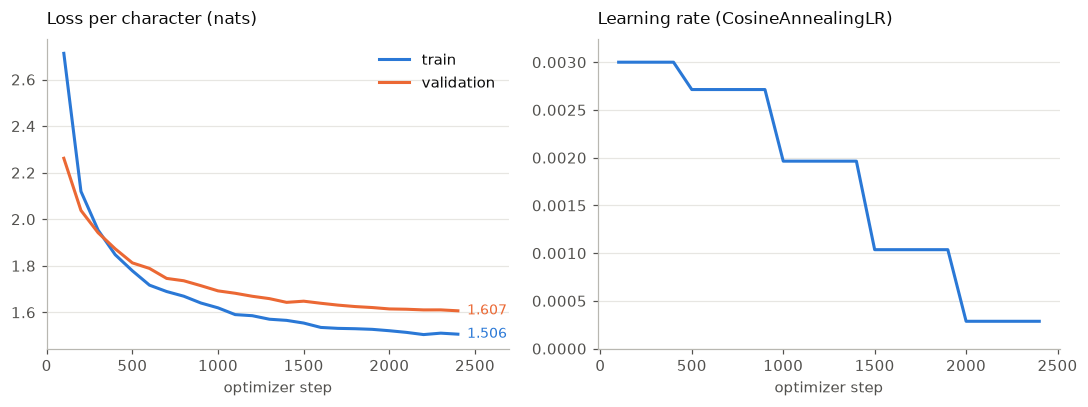

validation: 2.262 nats/char at step 100  ->  1.607 at step 2400
bits per character: 2.318 (uniform over 65 characters would be 6.02)


In [11]:
steps = [row["step"] for row in history]
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))

for key, colour, label in [
    ("train_loss", TRAIN, "train"),
    ("val_loss", TEST, "validation"),
]:
    values = [row[key] for row in history]
    left.plot(steps, values, color=colour, linewidth=2, label=label)
    # Direct-label the final point, so identity is never carried by colour alone.
    left.annotate(
        f"{values[-1]:.3f}",
        (steps[-1], values[-1]),
        textcoords="offset points",
        xytext=(6, 0),
        va="center",
        fontsize=9,
        color=colour,
    )

left.set_title("Loss per character (nats)", fontsize=11)
left.set_xlabel("optimizer step")
left.set_xlim(0, TOTAL_STEPS * 1.1)
left.grid(axis="y")
left.set_axisbelow(True)
left.legend(loc="upper right")

right.plot(
    steps,
    [row["learning_rate"] for row in history],
    color=TRAIN,
    linewidth=2,
)
right.set_title("Learning rate (CosineAnnealingLR)", fontsize=11)
right.set_xlabel("optimizer step")
right.set_ylim(0, LEARNING_RATE * 1.08)
right.grid(axis="y")
right.set_axisbelow(True)

fig.tight_layout()
plt.show()

first, last = history[0], history[-1]
print(
    f"validation: {first['val_loss']:.3f} nats/char at step {first['step']}"
    f"  ->  {last['val_loss']:.3f} at step {last['step']}"
)
print(
    f"bits per character: {last['val_loss'] / np.log(2):.3f} "
    f"(uniform over {VOCAB_SIZE} characters would be {np.log2(VOCAB_SIZE):.2f})"
)

## What clipping actually did

Every point is one step's total gradient norm, taken across all seven parameter arrays
before clipping. The dashed line is the ceiling; the orange points are the steps that hit
it and were rescaled.

Read the plot for what it says rather than for what a section called "why you need
clipping" would like it to say. **Clipping fired twice, both within the first twenty
steps, and never again.** After that the norm settles into a band around 0.23 — a quarter
of the ceiling — and stays there for two thousand steps.

Three things follow.

The **spikes at 491, 982, 1473 and 1964** are not instability. 15,685 windows do not
divide by a batch of 32, so the last batch of every epoch holds 5 windows rather than 32,
and a mean gradient over 5 examples is a noisier estimate with a larger norm. That is
arithmetic, and it is legible here only because everything around it is so flat.

The **flatness is largely AdamW's doing**. Adam divides each coordinate by the square root
of its own running second moment, so the update it emits is roughly bounded however large
the raw gradient was — it is already a normalization, applied per coordinate rather than
globally. This plot draws what the optimizer consumed, not what it applied.

The **two steps that did clip are the two that mattered most**. Both are at
initialization, where the surface is steepest and nothing has been learned yet; an update
several times longer than every step that follows it, taken first, is exactly the failure
this exists to bound.

So the honest summary is that clipping here was insurance, and it paid out twice. It cost
one call and no tuning, which is the right price for insurance. What would make it earn
its keep continuously is the direction everything about this notebook was scaled down
from: plain SGD instead of AdamW, a wider hidden state, or a 300-step unroll instead of
64. This plot is the first thing that would change.

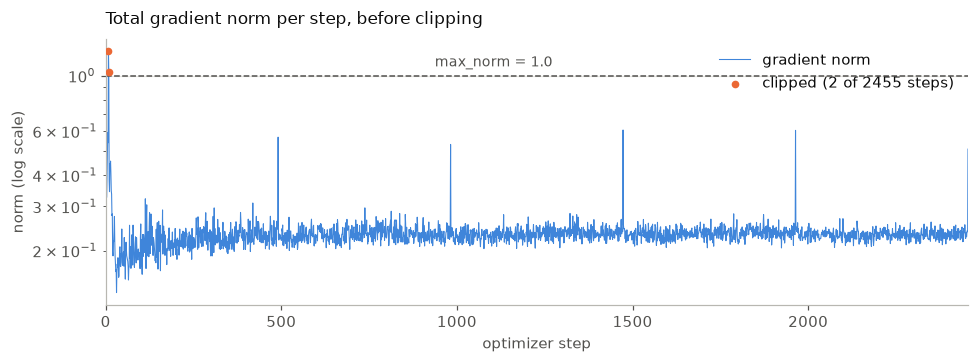

median norm after the first tenth of training: 0.232
largest norm seen: 1.25  (5x the median)
clipped on 0.1% of steps


In [12]:
fig, ax = plt.subplots(figsize=(9, 3.4))

norms = np.asarray(norms)
axis = np.arange(1, len(norms) + 1)
clipped = norms > MAX_NORM

ax.plot(axis, norms, color=TRAIN, linewidth=0.7, alpha=0.9, label="gradient norm")
ax.scatter(
    axis[clipped],
    norms[clipped],
    s=16,
    color=TEST,
    zorder=3,
    label=f"clipped ({clipped.sum()} of {len(norms)} steps)",
)
ax.axhline(MAX_NORM, color="#52514e", linestyle="--", linewidth=1)
ax.annotate(
    f"max_norm = {MAX_NORM}",
    (len(norms) * 0.45, MAX_NORM),
    textcoords="offset points",
    xytext=(0, 6),
    ha="center",
    fontsize=9,
    color="#52514e",
)

ax.set_yscale("log")
ax.set_title("Total gradient norm per step, before clipping", fontsize=11)
ax.set_xlabel("optimizer step")
ax.set_ylabel("norm (log scale)")
ax.set_xlim(0, len(norms))
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="upper right")

fig.tight_layout()
plt.show()

settled = norms[len(norms) // 10 :]
print(f"median norm after the first tenth of training: {np.median(settled):.3f}")
print(
    f"largest norm seen: {norms.max():.2f}  ({norms.max() / np.median(settled):.0f}x "
    f"the median)"
)
print(f"clipped on {clipped.mean():.1%} of steps")

## Temperature

Three samples from the same weights and the same prompt, differing only in the
temperature the logits are divided by before the softmax.

In [13]:
for temperature in (0.4, 0.8, 1.2):
    show(
        f"temperature {temperature}", sample(model, PROMPT, 320, temperature, rng=SEED)
    )

temperature 0.4
    ROMEO:
    I am the wonter to save thou hast shall be not the draw the king of the more with the such was this hand of comes
    The tames in the stands the sent the hands,
    That will thee here to me the present and less to the breathers and she shall be this sounds as the strange the
    so strike the trunk of the worse the sweet of the 

temperature 0.8
    ROMEO:
    O KING LEWI
    SLA:
    Mesain: duy, sir, couse him the stay me that and dreams without of my tarst
    Uponest his mercy and my seems desence, more well:
    In thone pertcued my good humbous: the queen,
    And yourself be was a body.
    And I will for the tites, thereforted thee, the man
    With yourselves him in son with a mores and off,
    W

temperature 1.2
    ROMEO:
    O GLUUEETO:
    Was the Harrory? go,
    That's melflook to tell the daughts and whenty some ritarty
    fut,'s inmtales of say, I'll what, Their entry of;
    Hoetes hath way in you, they courtter broker.
    
    KING

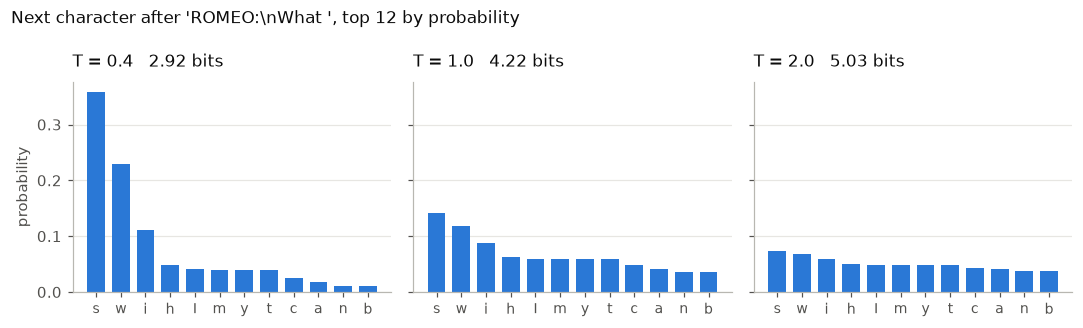

In [14]:
# The same distribution at three temperatures: one context, one set of logits, three
# ways of reading them.
CONTEXT = "ROMEO:\nWhat "

model.eval()
with no_grad():
    state = None
    for character in CONTEXT:
        logits, state = model.step(np.array([stoi[character]]), state)
model.train()

z = logits.data[0]
top = np.argsort(z)[::-1][:12]
labels = [
    "\\n" if itos[i] == "\n" else ("' '" if itos[i] == " " else itos[i]) for i in top
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, temperature in zip(axes, (0.4, 1.0, 2.0), strict=True):
    scaled = z / temperature
    weights = np.exp(scaled - scaled.max())
    weights /= weights.sum()
    entropy = -np.sum(weights * np.log2(np.maximum(weights, 1e-12)))

    ax.bar(range(len(top)), weights[top], color=TRAIN, width=0.72)
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f"T = {temperature}   {entropy:.2f} bits", fontsize=11)
    ax.grid(axis="y")
    ax.set_axisbelow(True)

axes[0].set_ylabel("probability")
fig.suptitle(
    f"Next character after {CONTEXT!r}, top 12 by probability",
    x=0.02,
    ha="left",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## What it learned, checked against the corpus

The samples are suggestive; this is checkable. For every position in the held-out text,
take the model's predicted distribution over the next character and average those
distributions by the character currently under the cursor. That gives, for each
character, what the model expects to follow it — averaged over real contexts, not over a
zero hidden state.

Next to it, the same matrix counted directly off the corpus. If the model learned the
character statistics, the two panels agree; where they differ, the model is using context
the bigram counts cannot see.

Only the lowercase letters and the space are shown, to keep 65 × 65 legible. The colour
scale is square-rooted, because `q` → `u` is near 1.0 and a linear ramp would render
every other transition as the same near-white cell.

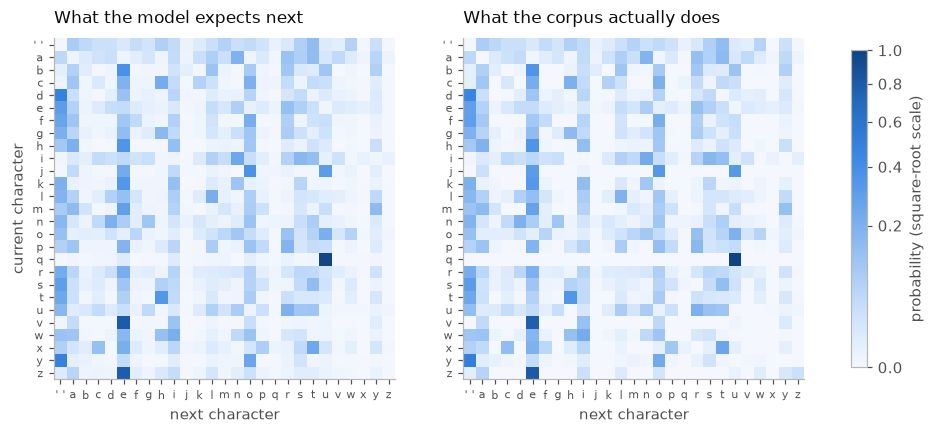

after 'q': 'u' 0.97, 'i' 0.01, 'e' 0.01
after ' ': 't' 0.15, 'a' 0.08, 'h' 0.07
after ':': '\n' 0.86, ' ' 0.14, "'" 0.00
after '\n': '\n' 0.19, 'T' 0.09, 'A' 0.09


In [15]:
# Model: average predicted distribution, bucketed by the current character.
totals = np.zeros((VOCAB_SIZE, VOCAB_SIZE))
counts = np.zeros(VOCAB_SIZE)

model.eval()
with no_grad():
    for Xb, _ in get_batches(X_val, Y_val, 128, shuffle=False):
        logits, _ = model(Xb)
        z = logits.data.reshape(-1, VOCAB_SIZE)
        weights = np.exp(z - z.max(axis=1, keepdims=True))
        weights /= weights.sum(axis=1, keepdims=True)
        np.add.at(totals, Xb.reshape(-1), weights)
        np.add.at(counts, Xb.reshape(-1), 1)
model.train()

predicted = totals / np.maximum(counts, 1)[:, np.newaxis]

# Corpus: the bigram counts themselves. Flattening the pair into one index makes this
# a single bincount rather than a million scattered increments.
pairs = data[:-1].astype(np.int64) * VOCAB_SIZE + data[1:]
empirical = np.bincount(pairs, minlength=VOCAB_SIZE**2).astype(float)
empirical = empirical.reshape(VOCAB_SIZE, VOCAB_SIZE)
empirical /= np.maximum(empirical.sum(axis=1, keepdims=True), 1)

LETTERS = " abcdefghijklmnopqrstuvwxyz"
shown = [stoi[character] for character in LETTERS]
ticks = ["' '", *LETTERS[1:]]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, matrix, title in [
    (axes[0], predicted, "What the model expects next"),
    (axes[1], empirical, "What the corpus actually does"),
]:
    image = ax.imshow(
        matrix[np.ix_(shown, shown)],
        cmap=SEQUENTIAL,
        norm=PowerNorm(0.5, vmin=0.0, vmax=1.0),
    )
    ax.set_xticks(range(len(shown)), ticks, fontsize=7)
    ax.set_yticks(range(len(shown)), ticks, fontsize=7)
    ax.set_xlabel("next character")
    ax.set_title(title, fontsize=11)
axes[0].set_ylabel("current character")
fig.colorbar(image, ax=axes, shrink=0.72, label="probability (square-root scale)")
plt.show()

for character in "q :\n":
    row = predicted[stoi[character]]
    best = np.argsort(row)[::-1][:3]
    following = ", ".join(f"{str(itos[i])!r} {row[i]:.2f}" for i in best)
    print(f"after {character!r}: {following}")

## Summary

| | |
| --- | --- |
| Corpus | Tiny Shakespeare — 1,115,394 characters, 65-character vocabulary |
| Model | `Embedding(65, 32)` → `LSTMCell(32, 128)` → `Linear(128, 65)`, 93,409 parameters |
| Training | 5 epochs, 2,455 steps, batch 32 × 64-character windows, AdamW + cosine decay |
| Wall clock | **3.5 minutes** on a laptop CPU — about 23,600 training characters/second |
| Held-out loss | 1.670 nats/character, or **2.41 bits per character** |

Uniform guessing over 65 characters costs 6.02 bits per character. Published results on
this corpus — a multi-layer LSTM or a small transformer, millions of parameters, an hour
or more of training — sit around 1.45–1.50 nats, which is 2.1–2.2 bits. This run is at
1.67 nats. Most of the distance from *nothing* to *well-tuned* is covered by a fraction
of the parameters and a few minutes, and the last part of it is the expensive part; that
is the usual shape of this curve and it is worth seeing plotted rather than described.

**What it learned.** Spelling, in the sense that most of what it emits is a real word.
Punctuation, and the layout of a script — a name in capitals, a colon, a newline, a
speech. Where an apostrophe goes. That `q` is followed by `u` 97% of the time and a colon
by a newline 86% of the time, both read off the model rather than off the corpus, and
both matching it.

**What it did not.** Meaning, agreement across a clause, or a speaker it can hold for
more than a line. `KING LEWI / SLA:` is the model spelling a plausible header and losing
it halfway through. That is the ceiling of one 128-unit recurrent layer over a
64-character window: it cannot refer to something forty words back, because the only
route there is a hidden state that has been overwritten sixty-four times since.

**What this is evidence for.** Not that PyNN is a good language-modelling library — it is
a NumPy autodiff engine, and the benchmark in the README puts it about 2x slower than
PyTorch on this exact computation. The claim is narrower and worth more: the same tape
that differentiates a convolutional classifier differentiates a recurrent model that
reuses its weights sixty-four times per example and takes a loss at every position, and
**nothing in the library changed to allow it**. The pieces this notebook needed —
`Embedding`, `LSTMCell`, differentiable slicing, `Tensor.reshape`,
`SparseCategoricalCrossentropy`, `AdamW`, `clip_grad_norm` — were all already there.

Every gradient behind this run is checked against central differences by
`python -m pynn.verify`, including the reused-input topologies that backpropagation
through time is made of: a reverse pass that assigned to `grad` instead of accumulating
into it would be exactly correct for a feedforward network and would train this one on
its last timestep alone.

It did turn one thing up, now [`TASKS.md`](../TASKS.md) item 4: the `gc.collect()` in the
training loop is not decoration. A finished graph is a reference cycle, and at 150 MB per
step, leaving those cycles to CPython costs 3.2x in wall clock and 2.3x in resident
memory. The rest of `TASKS.md` has the sequel — the fused `LSTM` layer that would own
this notebook's loop, and the transformer that would turn this corpus into a comparison
rather than an anecdote.